## Задание
Проведении А/А-теста, нарисовать гистограмму получившихся p-value и посчитать долю p-value, оказавшихся ниже порога значимости в 0.05. 
* Берём данные АА-теста из следующего диапазона: с '2025-11-14' по '2025-11-20'.
* Из групп 2 и 3 берём подвыборки без возвращения размером в 500 юзеров.
* Сравниваем их t-тестом и сохраняем p-value
* Повторяем это 10000 раз.

In [1]:
import pandas as pd
import pandahouse as ph
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")  # Настройка стиля графика
from scipy.stats import mannwhitneyu

In [2]:
connection = {'host': 'http://clickhouse.lab.karpov.courses:8123',
'database':'simulator_20251220',
'user':'student',
'password':'dpo_python_2020'
}

In [3]:
q = """SELECT uniqExact (user_id)
FROM simulator_20251220.feed_actions
WHERE toDate(time) >= '2025-11-14' and toDate(time) <= '2025-11-20'
"""

In [4]:
ph.read_clickhouse(q, connection=connection)

,uniqExact(user_id)
0,41997


In [5]:
q = """
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20251220.feed_actions 
WHERE toDate(time) between '2025-11-14' and '2025-11-20'
    and exp_group in (2,3)
GROUP BY exp_group, user_id
"""

In [6]:
df = ph.read_clickhouse(q, connection=connection)

In [7]:
df.groupby('exp_group').count()

,user_id,likes,views,ctr
exp_group,,,,
2,8362,8362,8362,8362
3,8425,8425,8425,8425


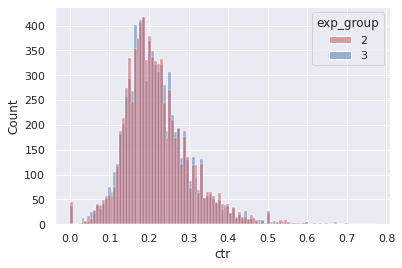

In [8]:
# Сделаем графики в seaborn покрупнее
sns.set(rc={'figure.figsize':(11.7,8.27)})

groups = sns.histplot(data = df, 
              x='ctr', 
              hue='exp_group', 
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)

In [9]:
stats.ttest_ind(df[df.exp_group == 2].ctr,
                df[df.exp_group == 3].ctr,
                equal_var=False)

Ttest_indResult(statistic=0.6617303509169987, pvalue=0.508153138292614)

Визуально и статистически (pvalue=0.508) группы пользователей 2 и 3 похожи/ различия допустимы

In [10]:
print(mannwhitneyu(df[df.exp_group == 2].ctr,
                df[df.exp_group == 3].ctr))

print('Отличие не прокрасилось')

A_gt_B = 0
for _ in range(10000):
    A_gt_B+= df[df.exp_group == 2].ctr.sample().values[0] > df[df.exp_group == 3].ctr.sample().values[0]
    
print('В', A_gt_B/100, '% случаев A > B. Должно получиться около 50%')


MannwhitneyuResult(statistic=35290681.5, pvalue=0.8340910379715747)
Отличие не прокрасилось
В 50.37 % случаев A > B. Должно получиться около 50%


# Из групп 2 и 3 берём подвыборки без возвращения размером в 500 юзеров, повторяем это 10000 раз
* Сравниваем их t-тестом и сохраняем p-value
* Рисуем гистограмму получившихся p-value и считаем долю p-value, оказавшихся ниже порога значимости в 0.05. 

In [11]:
group_2 = df[df.exp_group == 2].copy()
group_3 = df[df.exp_group == 3].copy()

In [12]:
# Проведем 10000 тестов на выборках по 500 пользователей в групппах 2 и 3
# frac - доля от общего количества датафрейма (группы)

ps_values = []

for i in range(10000):
    _, p_value = stats.ttest_ind(group_2.ctr.sample(frac=0.06, replace=True),
                                group_3.ctr.sample(frac=0.06, replace=True),
                                equal_var = False)
    ps_values.append(p_value)

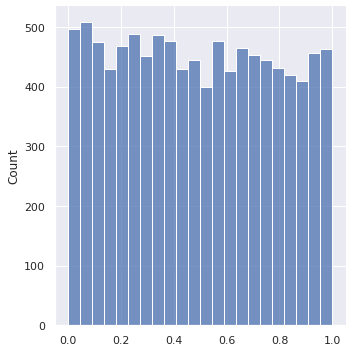

In [13]:
sns.displot(ps_values)

In [14]:
# найдем количество p-value, которые меньше или равны 0,05.

sum(np.array(ps_values)<=0.05)/10000

0.054

# Вывод

Около 5% p-value оказались меньше или равны 0,05. Из этого следует, что АА-тест проведен успешно, пользователи разбиты на статистически равные группы, что позволяет проводить АВ-тест на этих или других группах из этой разбивки пользователей.